In [2]:
import pandas as pd

df = pd.read_csv('/content/estatisticas_jogos.csv')

#Diagnóstico do Dataset

In [38]:
df.head()

,Time,Jogo,Gols marcados,Gols sofridos,Chutes a gol,Finalizações,Escanteios,Posse (%),Amarelos,Vermelhos,Impedimentos,Faltas,saldo_gols,eficiencia_ofensiva
0,Flamengo,1,3,1,6,17,4,47.261041,3,0,1,14,2,0.176471
1,Flamengo,2,2,0,5,5,1,44.963987,1,0,1,9,2,0.400000
2,Flamengo,3,3,1,5,7,3,49.676458,1,0,1,12,2,0.428571
3,Flamengo,4,2,2,5,8,6,40.354094,2,0,0,13,0,0.250000
4,Flamengo,5,3,1,5,11,1,43.861091,1,0,2,8,2,0.272727


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           400 non-null    object 
 1   Jogo           400 non-null    int64  
 2   Gols marcados  400 non-null    int64  
 3   Gols sofridos  400 non-null    int64  
 4   Chutes a gol   400 non-null    int64  
 5   Finalizações   400 non-null    int64  
 6   Escanteios     400 non-null    int64  
 7   Posse (%)      400 non-null    float64
 8   Amarelos       400 non-null    int64  
 9   Vermelhos      400 non-null    float64
 10  Impedimentos   400 non-null    int64  
 11  Faltas         400 non-null    int64  
dtypes: float64(2), int64(9), object(1)
memory usage: 37.6+ KB


In [43]:
df.shape

(400, 14)

In [15]:
df.isnull().sum()

,0
Time,0
Jogo,0
Gols marcados,0
Gols sofridos,0
Chutes a gol,0
Finalizações,0
Escanteios,0
Posse (%),0
Amarelos,0
Vermelhos,0


# Criação de colunas

In [17]:
#criação da coluna saldo de gols

df['saldo_gols'] = df['Gols marcados'] - df['Gols sofridos']

In [37]:
# criação da coluna Eficiência ofensiva

df['eficiencia_ofensiva'] = df['Gols marcados'] / df['Finalizações']

# Análise exploratória de dados (AED)

In [5]:
df.describe()

,Jogo,Gols marcados,Gols sofridos,Chutes a gol,Finalizações,Escanteios,Posse (%),Amarelos,Vermelhos,Impedimentos,Faltas
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,25.500000,1.977500,0.902500,4.710000,11.617500,4.237500,48.818848,1.815000,0.002625,1.772500,13.285000
std,14.448942,0.733716,0.673891,2.067992,3.482314,2.065614,7.138849,0.766318,0.016810,0.971134,2.444117
min,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000,35.000000,0.000000,0.000000,0.000000,6.000000
25%,13.000000,2.000000,0.000000,3.000000,9.000000,3.000000,43.770103,1.000000,0.000000,1.000000,12.000000
50%,25.500000,2.000000,1.000000,5.000000,12.000000,4.000000,49.003573,2.000000,0.000000,2.000000,13.000000
75%,38.000000,2.000000,1.000000,6.000000,14.000000,6.000000,53.598532,2.000000,0.000000,2.000000,15.000000
max,50.000000,4.000000,3.000000,11.000000,21.000000,10.000000,68.000000,4.000000,0.190000,5.000000,23.000000


In [7]:
# Times com mais gols marcados

df.groupby('Time')['Gols marcados'].sum().sort_values(ascending=False)

,Gols marcados
Time,
Palmeiras,111
Flamengo,109
Atlético-MG,108
Botafogo,103
Grêmio,101
Vasco,89
Cuiabá,85
Bahia,85


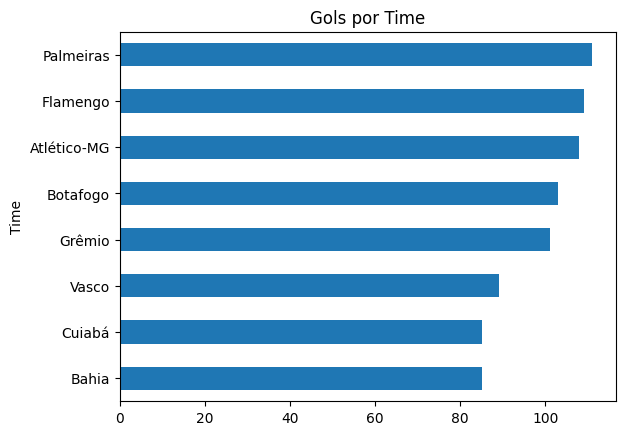

In [24]:
# Gráfico de timescom mais gols marcados

import matplotlib.pyplot as plt

df.groupby('Time')['Gols marcados'].sum().sort_values().plot(kind='barh')
plt.title('Gols por Time')
plt.show()

In [8]:
# Times com mais gols sofridos

df.groupby('Time')['Gols sofridos'].sum().sort_values(ascending=False)

,Gols sofridos
Time,
Cuiabá,57
Vasco,50
Grêmio,47
Botafogo,46
Bahia,45
Atlético-MG,44
Flamengo,39
Palmeiras,33


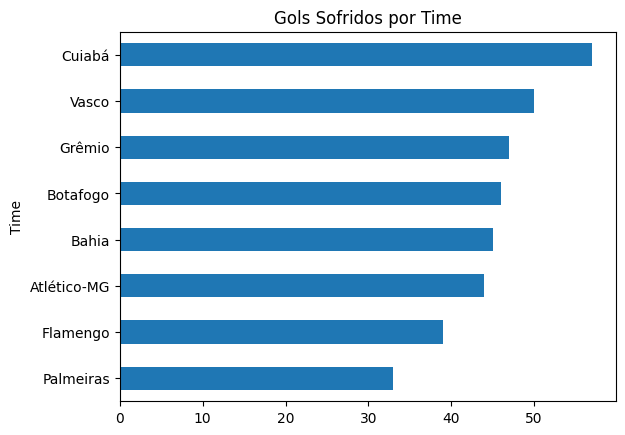

In [26]:
# Gráfico de Times com mais gols sofridos

df.groupby('Time')['Gols sofridos'].sum().sort_values().plot(kind='barh')
plt.title('Gols Sofridos por Time')
plt.show()

In [9]:
# Times com mais escanteios

df.groupby('Time')['Escanteios'].sum().sort_values(ascending=False)

,Escanteios
Time,
Atlético-MG,239
Palmeiras,229
Grêmio,222
Flamengo,221
Vasco,218
Botafogo,195
Cuiabá,194
Bahia,177


In [10]:
# Times com mais finalizações

df.groupby('Time')['Finalizações'].mean().sort_values(ascending=False)

,Finalizações
Time,
Flamengo,12.38
Bahia,12.34
Palmeiras,12.26
Atlético-MG,12.00
Grêmio,11.42
Vasco,11.26
Botafogo,10.92
Cuiabá,10.36


In [11]:
# Times com mais chutes a gol

df.groupby('Time')['Chutes a gol'].mean().sort_values(ascending=False)

,Chutes a gol
Time,
Atlético-MG,5.48
Palmeiras,4.98
Flamengo,4.70
Botafogo,4.70
Vasco,4.52
Cuiabá,4.52
Grêmio,4.40
Bahia,4.38


In [12]:
# Times com maior porcentagem de posse de bola

df.groupby('Time')['Posse (%)'].mean().sort_values(ascending=False)

,Posse (%)
Time,
Botafogo,51.851490
Bahia,49.038090
Flamengo,48.763514
Palmeiras,48.568258
Grêmio,48.335055
Atlético-MG,48.153245
Vasco,48.083697
Cuiabá,47.757433


In [20]:
# Time com mais saldo de gols

df.groupby('Time')['saldo_gols'].sum().sort_values(ascending=False)

,saldo_gols
Time,
Palmeiras,78
Flamengo,70
Atlético-MG,64
Botafogo,57
Grêmio,54
Bahia,40
Vasco,39
Cuiabá,28


In [41]:
# Time com maior eficiência ofensiva

df.groupby('Time')['eficiencia_ofensiva'].sum().sort_values(ascending=False)

,eficiencia_ofensiva
Time,
Botafogo,10.398877
Cuiabá,10.077641
Atlético-MG,10.037416
Palmeiras,9.969684
Flamengo,9.870333
Grêmio,9.634718
Vasco,8.478763
Bahia,7.270734


In [40]:
# correlação

df.drop(columns=['Time']).corr()

,Jogo,Gols marcados,Gols sofridos,Chutes a gol,Finalizações,Escanteios,Posse (%),Amarelos,Vermelhos,Impedimentos,Faltas,saldo_gols,eficiencia_ofensiva
Jogo,1.000000,-0.027069,0.019948,-0.027092,0.054269,0.031028,0.014624,0.061115,NaN,0.021523,-0.005110,-0.034503,-0.065234
Gols marcados,-0.027069,1.000000,0.061447,0.109661,-0.002396,0.051491,0.042918,-0.038624,NaN,-0.070515,-0.092848,0.717233,0.694081
Gols sofridos,0.019948,0.061447,1.000000,-0.027534,-0.106711,0.007675,-0.070406,-0.039869,NaN,0.015807,-0.141339,-0.651445,0.113614
Chutes a gol,-0.027092,0.109661,-0.027534,1.000000,-0.034931,0.096544,-0.061018,-0.040265,NaN,-0.006726,0.003005,0.102580,0.088245
Finalizações,0.054269,-0.002396,-0.106711,-0.034931,1.000000,-0.074445,0.031748,-0.039732,NaN,0.050538,0.058483,0.072680,-0.616667
Escanteios,0.031028,0.051491,0.007675,0.096544,-0.074445,1.000000,-0.017363,-0.065589,NaN,0.053240,0.029748,0.033782,0.059639
Posse (%),0.014624,0.042918,-0.070406,-0.061018,0.031748,-0.017363,1.000000,-0.042368,NaN,0.016563,0.029096,0.081777,0.000225
Amarelos,0.061115,-0.038624,-0.039869,-0.040265,-0.039732,-0.065589,-0.042368,1.000000,NaN,-0.026386,-0.021290,-0.001525,-0.010792
Vermelhos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Impedimentos,0.021523,-0.070515,0.015807,-0.006726,0.050538,0.053240,0.016563,-0.026386,NaN,1.000000,0.033720,-0.064636,-0.085189


Ao observar o conjunto de dados com 400 partidas distribuídas entre 8 times, alguns padrões se destacam com clareza.

O Palmeiras se consolida como o time de melhor desempenho. Liderou em gols marcados (111), teve a melhor defesa (apenas 33 sofridos) e alcançou o maior saldo positivo (+78). Não por acaso, esses números refletem um equilíbrio, o time foi eficiente tanto para criar oportunidades de gols quanto para se defender.

Por outro lado, o Cuiabá concentrou as piores métricas em praticamente todas as variáveis analisadas: mais gols sofridos (57), menos finalizações por jogo (10,36) e menor posse de bola (47,8%). Esse conjunto revela um time com dificuldade tanto de chegar ao ataque quanto de se defender, o que resulta no menor saldo geral (+28).

O achado mais relevante do projeto, porém, está na relação entre posse de bola e gols marcados. O Botafogo domina a posse com média de 51,9%, a maior entre todos os times, mas termina apenas em 4º lugar em gols marcados. Já Palmeiras e Flamengo, com posses entre (~48%), lideram a produção ofensiva. A correlação calculada no notebook confirma esse comportamento: a posse quase não influencia as finalizações nem os gols.

O que de fato separa os times mais produtivos é a eficiência na hora de finalizar. O Atlético-MG, por exemplo, lidera em chutes a gol por partida (5,48) e está entre os três primeiros em gols marcados, o que indica que mais do que criar volume de jogadas, o time acerta melhor quando decide arriscar.

Em resumo, os dados mostram que dominar a bola não garante dominar o placar. O desempenho real é determinado pela combinação de eficiência ofensiva e solidez defensiva, e o Palmeiras foi o time que melhor equilibrou esses dois lados ao longo das 50 partidas analisadas.